In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
import pandas as pd

In [1]:
import pandas as pd
from io import StringIO

data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')

In [ ]:
EDA(Exploratory Data Analysis)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

              Sales
count    108.000000
mean   14595.111111
std     4525.213913
min     5568.000000
25%    11391.250000
50%    14076.000000
75%    17595.750000
max    26099.000000


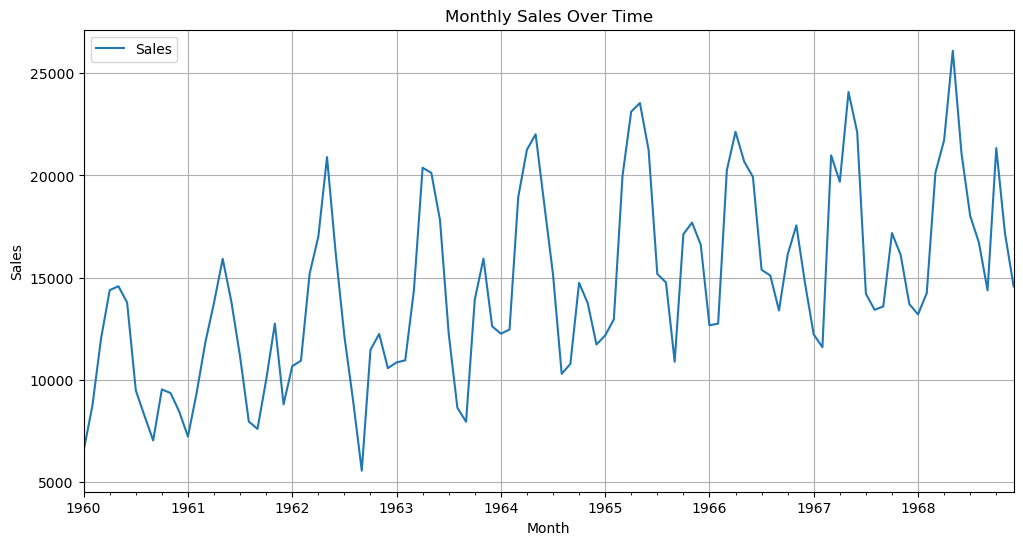

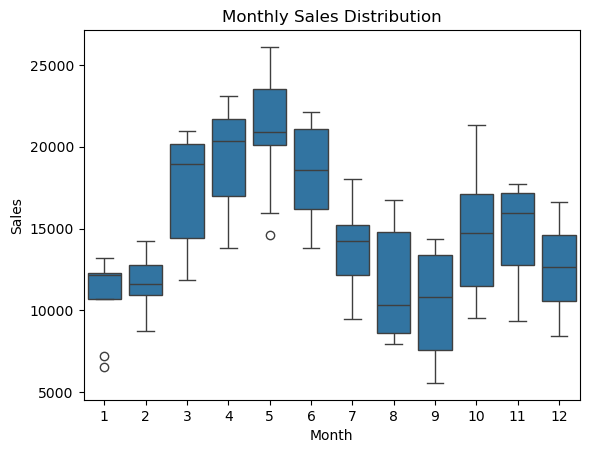

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


print(df.describe())
df.plot(title='Monthly Sales Over Time', figsize=(12,6))
plt.ylabel("Sales")
plt.grid(True)
plt.show()


sns.boxplot(x=df.index.month, y=df["Sales"])
plt.title("Monthly Sales Distribution")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pandas.plotting import autocorrelation_plot

In [ ]:
print("🟢 Data Summary:\n", df.describe())
print("\n🟡 Missing values:\n", df.isnull().sum())
print("\n🧠 Dataset shape:", df.shape)

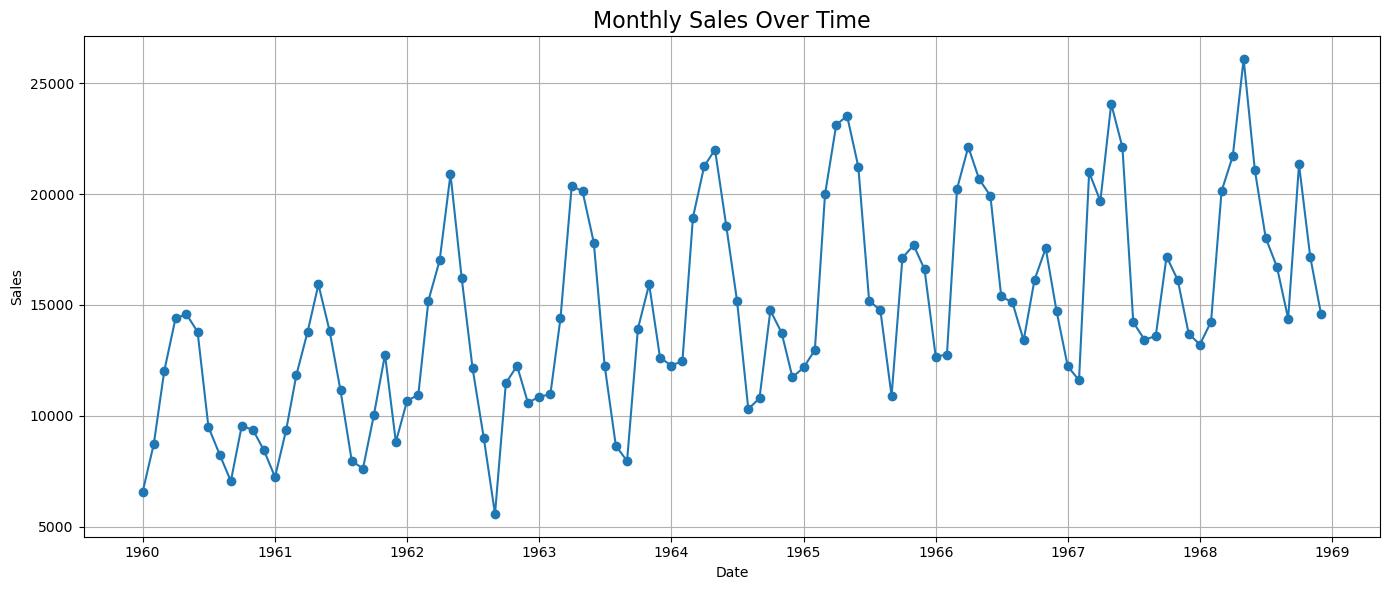

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Sales'], marker='o')
plt.title('Monthly Sales Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\1750813795.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')


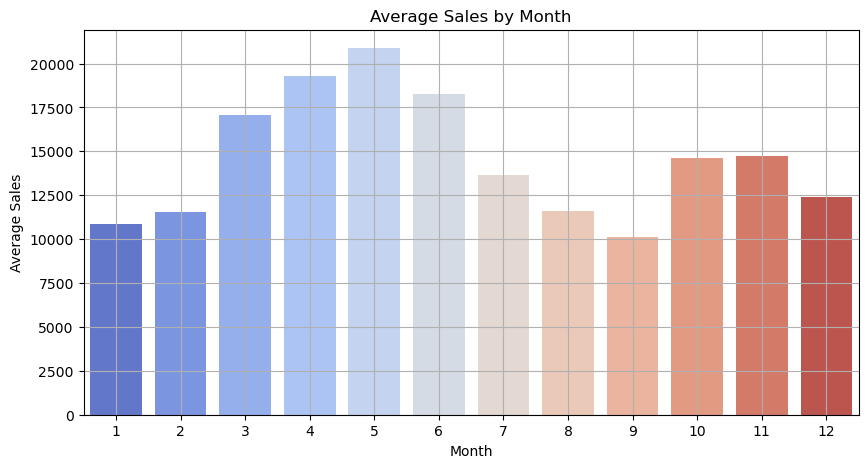

In [15]:
df['Month_Num'] = df.index.month

monthly_avg = df.groupby('Month_Num')['Sales'].mean()


plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

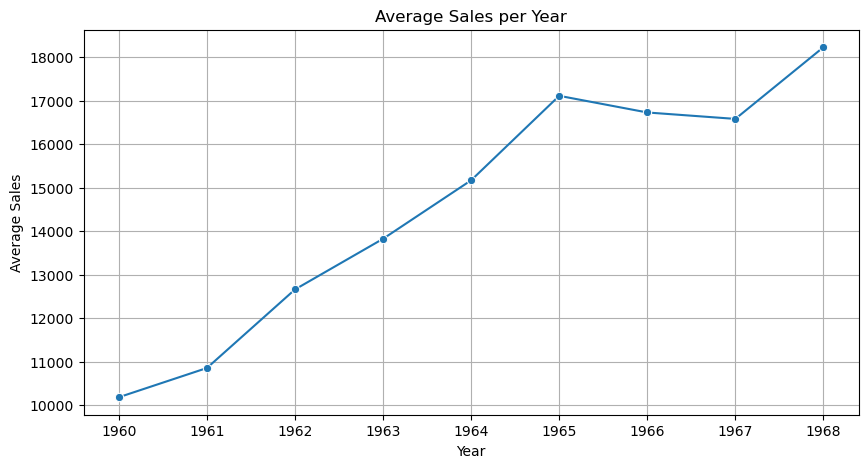

In [17]:
df['Year'] = df.index.year
yearly_avg = df.groupby('Year')['Sales'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o')
plt.title("Average Sales per Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

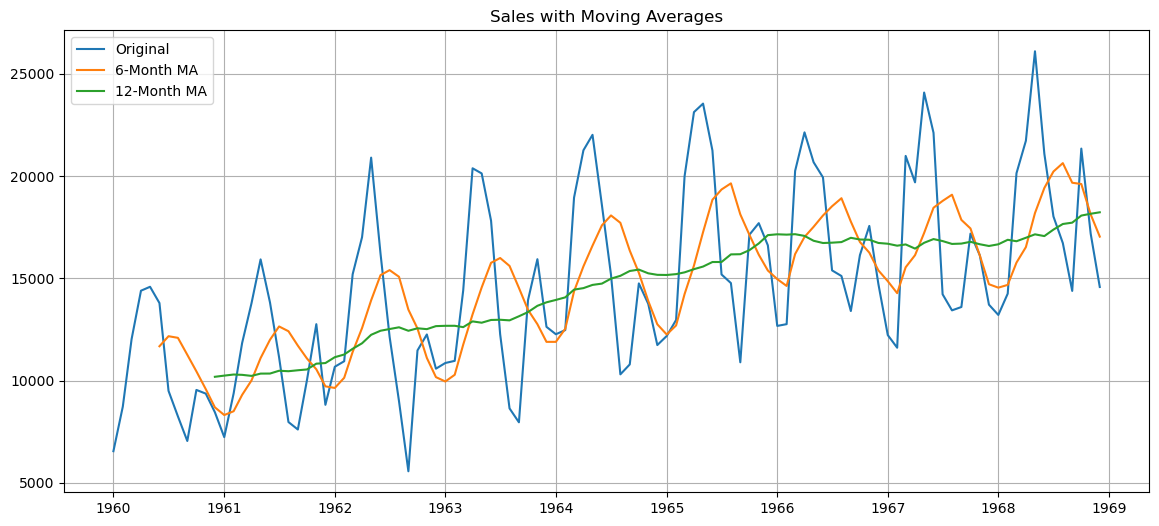

In [19]:
df['MA_6'] = df['Sales'].rolling(window=6).mean()
df['MA_12'] = df['Sales'].rolling(window=12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df['Sales'], label='Original')
plt.plot(df['MA_6'], label='6-Month MA')
plt.plot(df['MA_12'], label='12-Month MA')
plt.title("Sales with Moving Averages")
plt.legend()
plt.grid(True)
plt.show()

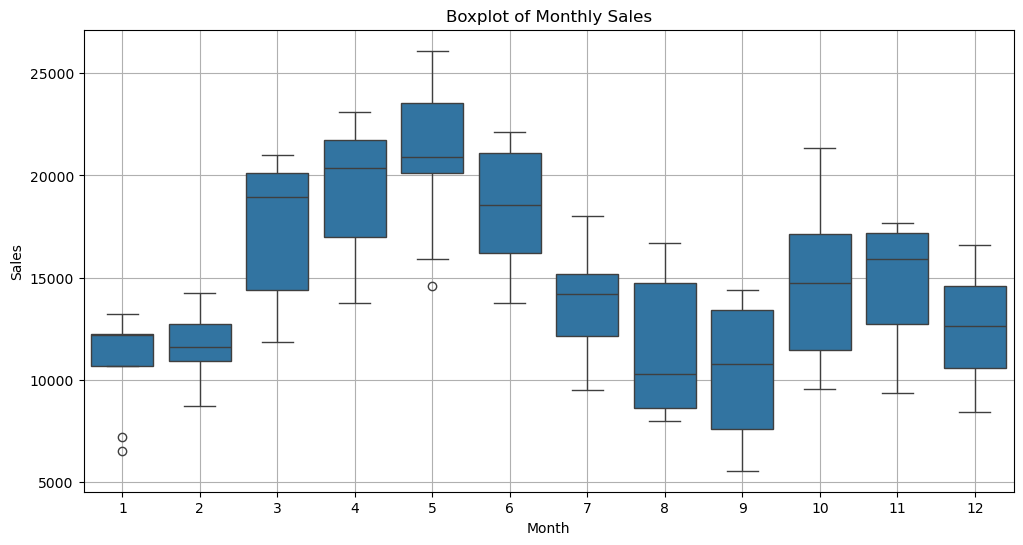

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Sales', data=df)
plt.title("Boxplot of Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

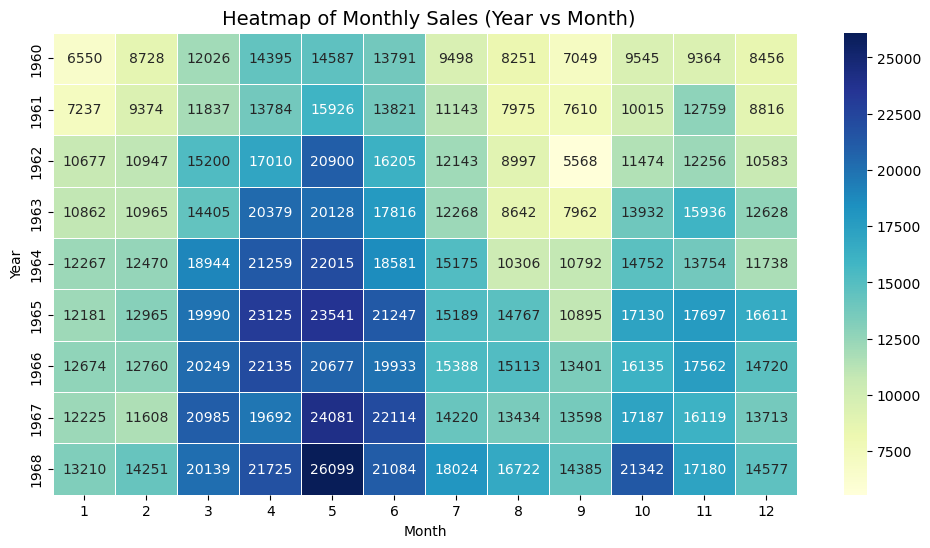

In [25]:
df['Month_Num'] = df.index.month
df['Year'] = df.index.year


heatmap_data = df.pivot_table(index='Year', columns='Month_Num', values='Sales')


plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5)
plt.title(" Heatmap of Monthly Sales (Year vs Month)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()


C:\Users\ldivy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


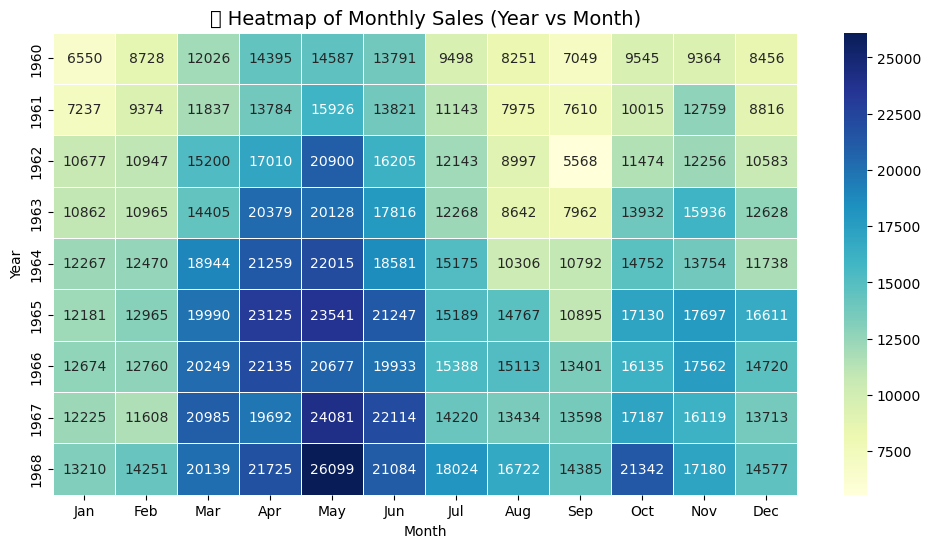

In [27]:
import calendar


heatmap_data.columns = [calendar.month_abbr[m] for m in heatmap_data.columns]


plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5)
plt.title("📊 Heatmap of Monthly Sales (Year vs Month)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

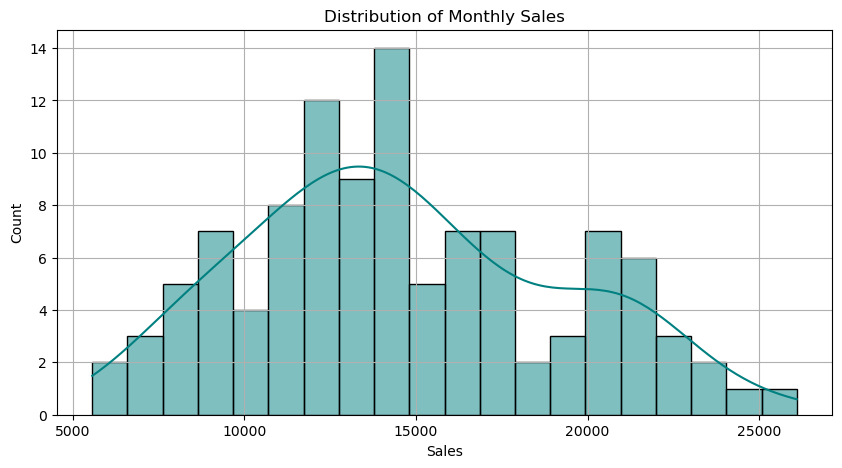

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, bins=20, color='teal')
plt.title("Distribution of Monthly Sales")
plt.xlabel("Sales")
plt.grid(True)
plt.show()

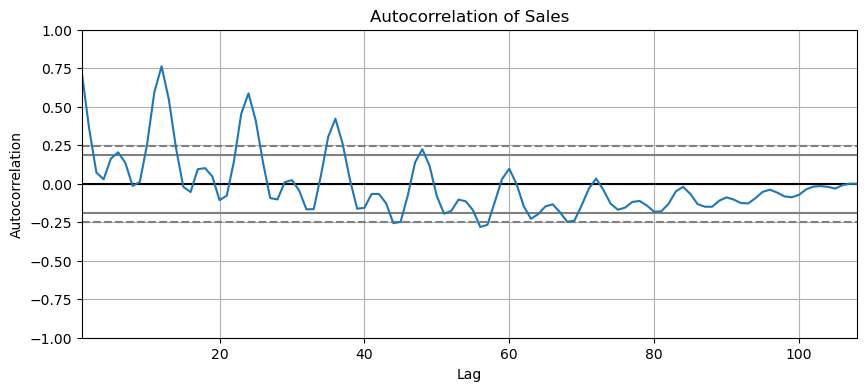

In [33]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
autocorrelation_plot(df['Sales'])
plt.title("Autocorrelation of Sales")
plt.grid(True)
plt.show()

In [ ]:
Seasonality

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

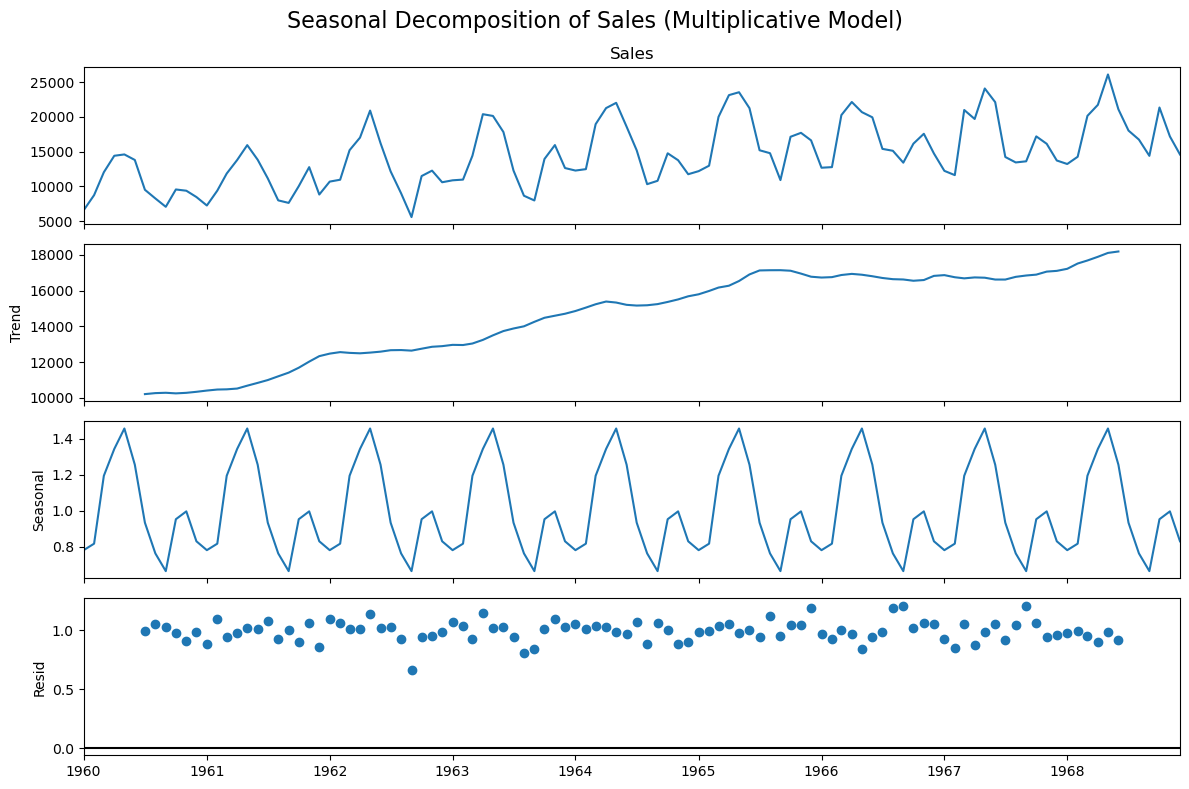

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


df = df.asfreq('MS') 


decomposition = seasonal_decompose(df['Sales'], model='multiplicative', period=12)


plt.rcParams.update({'figure.figsize': (12, 8)})
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Sales (Multiplicative Model)", fontsize=16)
plt.tight_layout()
plt.show()

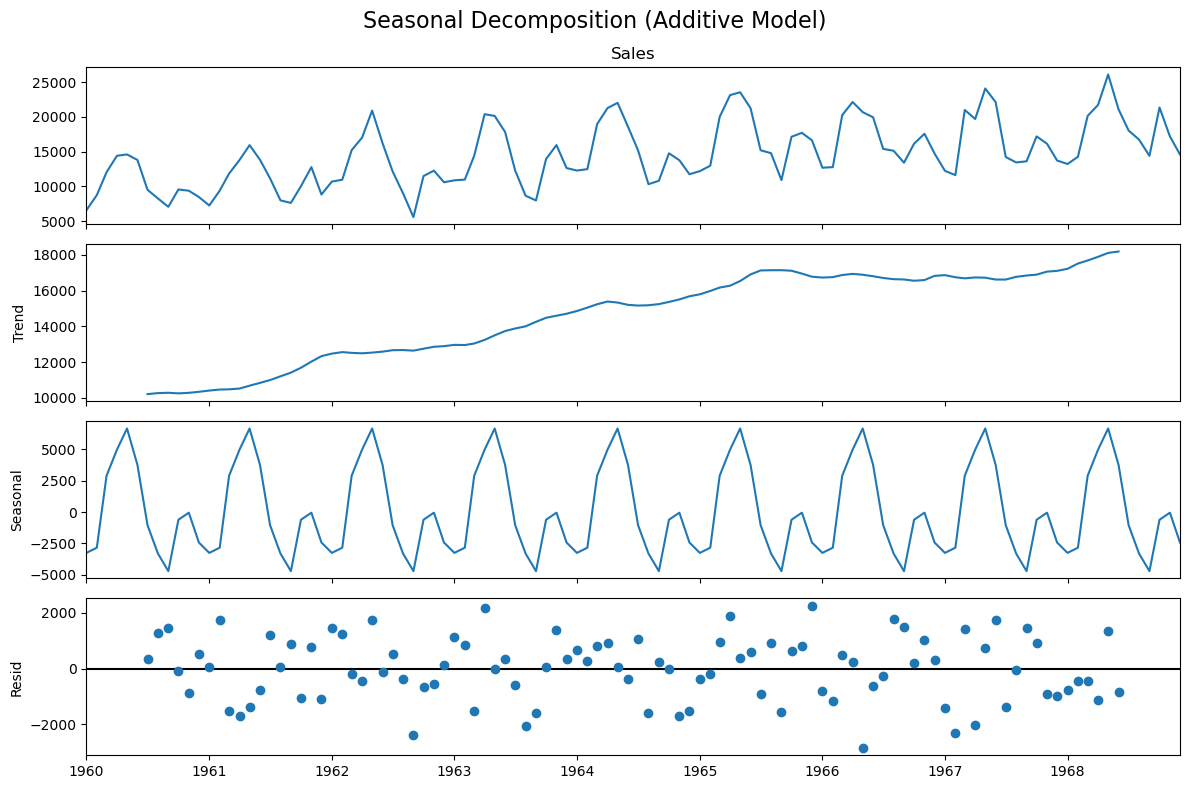

In [39]:
decomp_add = seasonal_decompose(df['Sales'], model='additive', period=12)
decomp_add.plot()
plt.suptitle("Seasonal Decomposition (Additive Model)", fontsize=16)
plt.tight_layout()
plt.show()

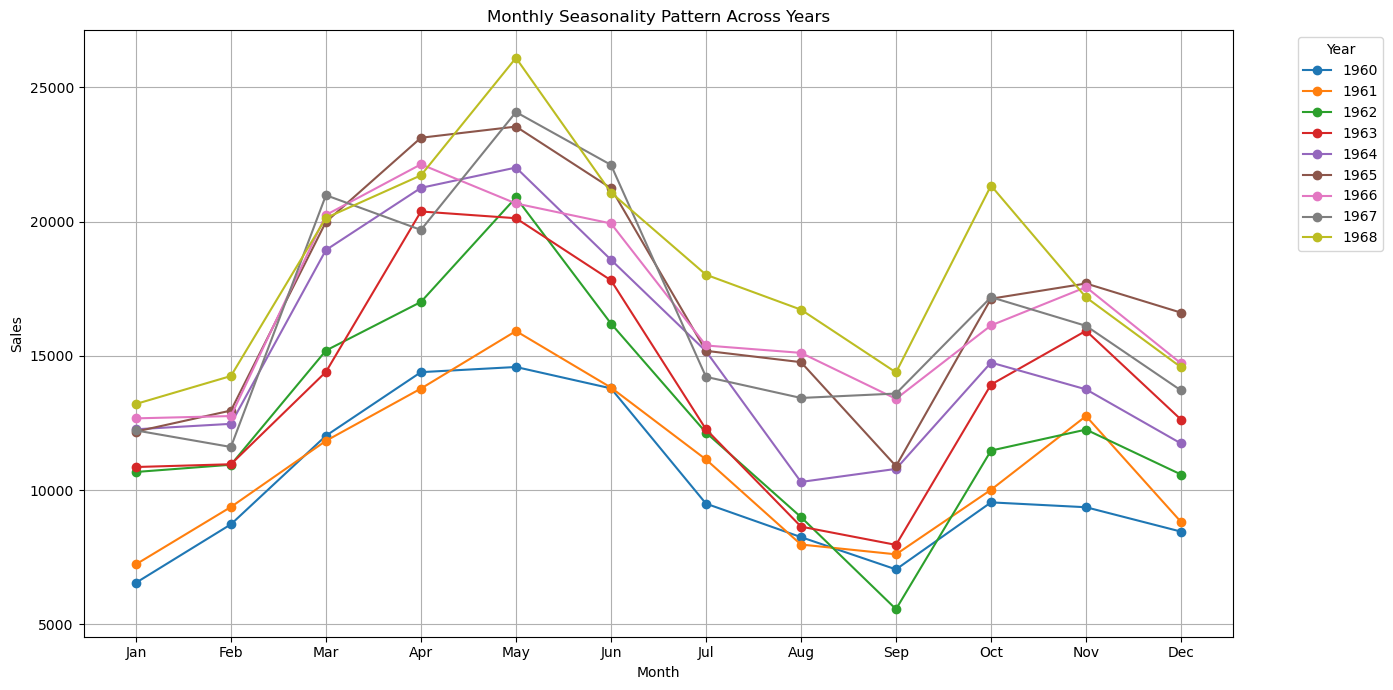

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import calendar


df['Month_Num'] = df.index.month
df['Year'] = df.index.year


seasonal_pivot = df.pivot_table(index='Month_Num', columns='Year', values='Sales')


plt.figure(figsize=(14, 7))
for year in seasonal_pivot.columns:
    plt.plot(seasonal_pivot.index, seasonal_pivot[year], marker='o', label=str(year))

plt.title('Monthly Seasonality Pattern Across Years')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\339449601.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="viridis")


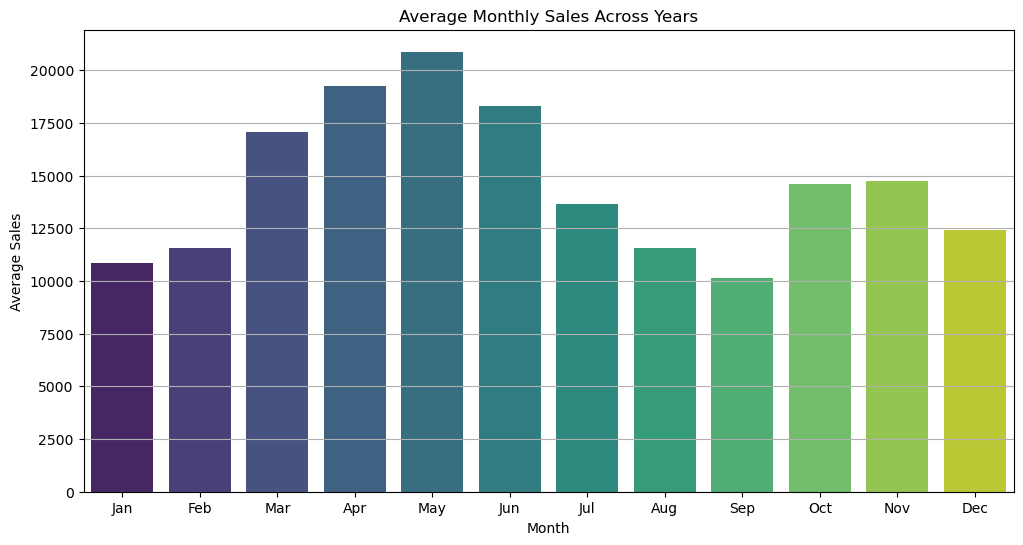

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar


df['Month_Num'] = df.index.month
df['Month_Name'] = df['Month_Num'].apply(lambda x: calendar.month_abbr[x])


monthly_avg = df.groupby('Month_Name')['Sales'].mean()


month_order = list(calendar.month_abbr[1:])
monthly_avg = monthly_avg.reindex(month_order)


plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="viridis")

plt.title("Average Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(axis='y')
plt.show()

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\3307255133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month_Name', y='Sales', data=df, order=calendar.month_abbr[1:], palette='Set2')


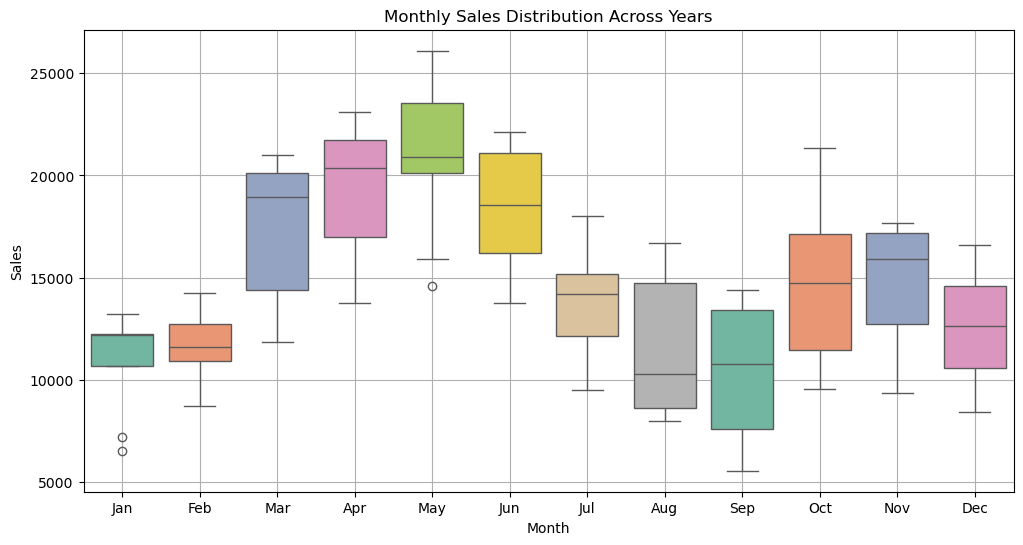

In [49]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month_Name', y='Sales', data=df, order=calendar.month_abbr[1:], palette='Set2')
plt.title("Monthly Sales Distribution Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

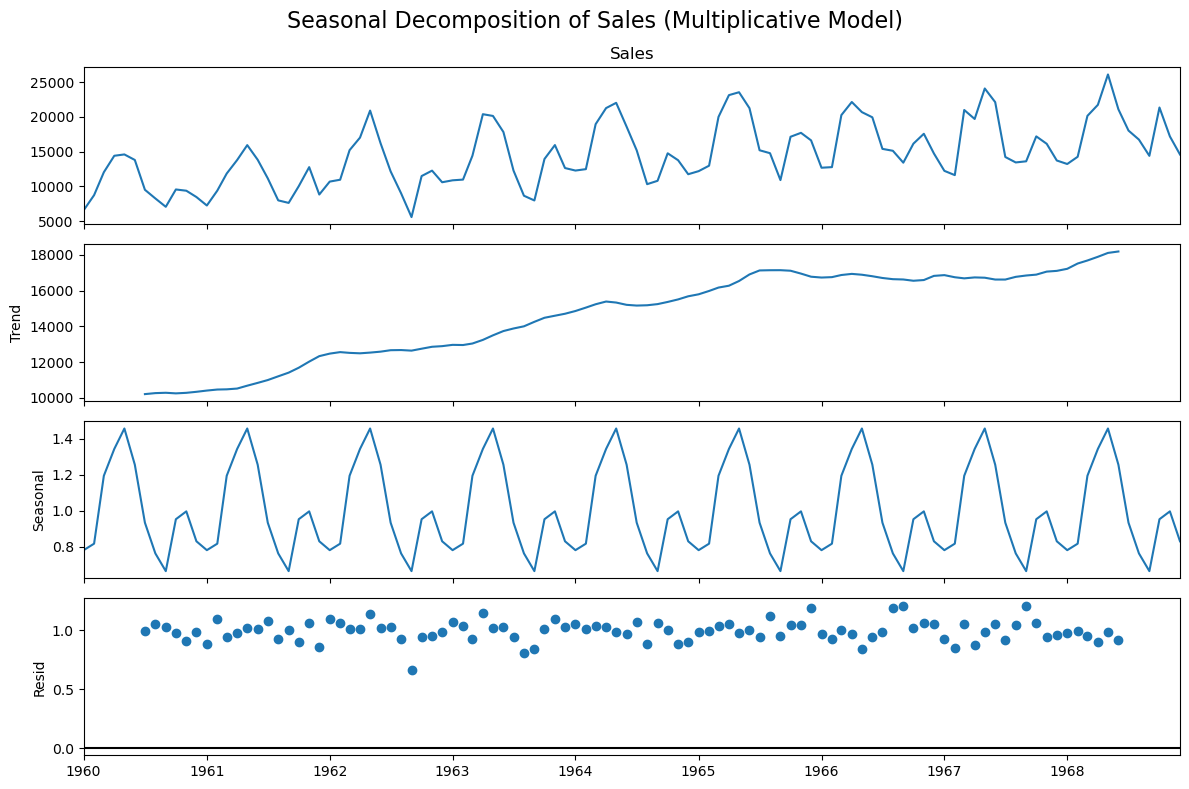

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\2422417830.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='magma')


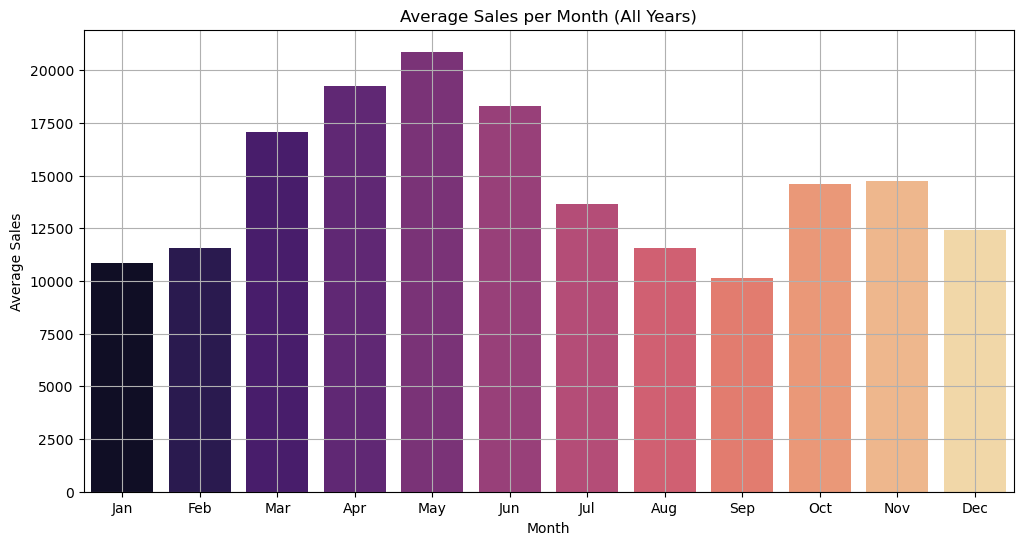

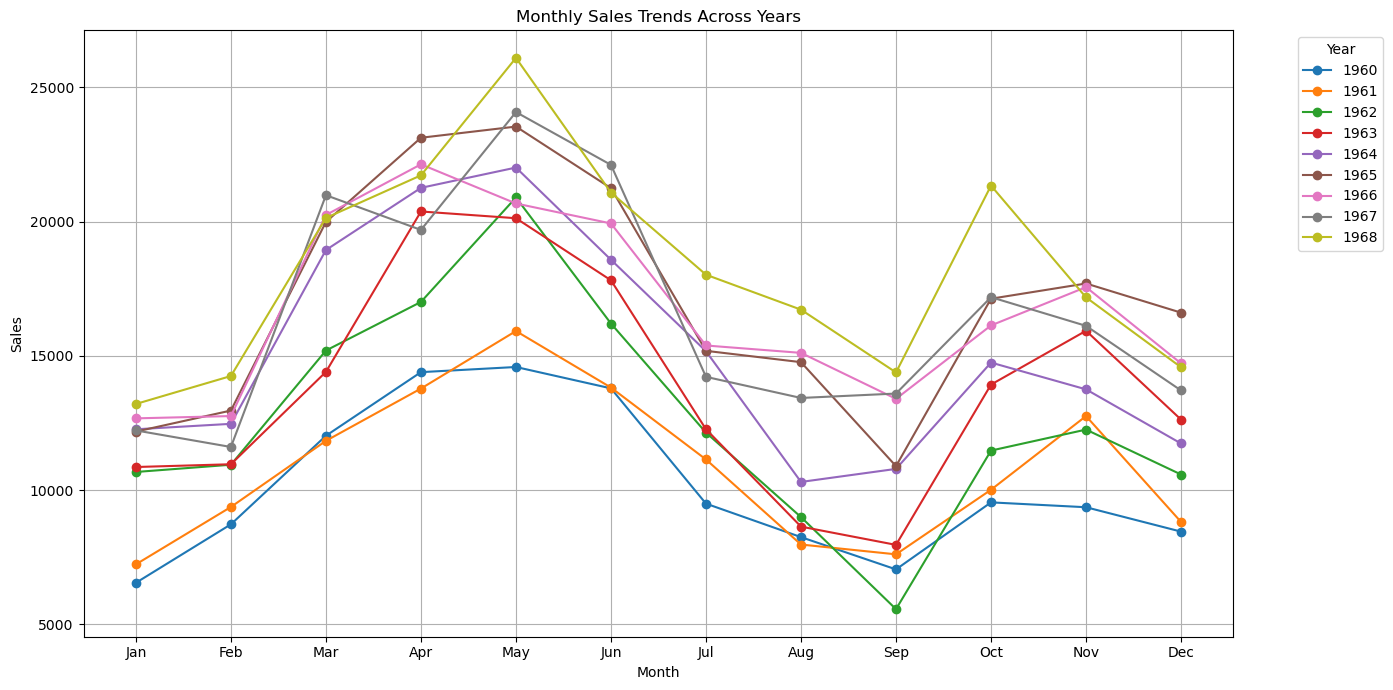

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\2422417830.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month_Name', y='Sales', data=df, order=calendar.month_abbr[1:], palette='Set2')


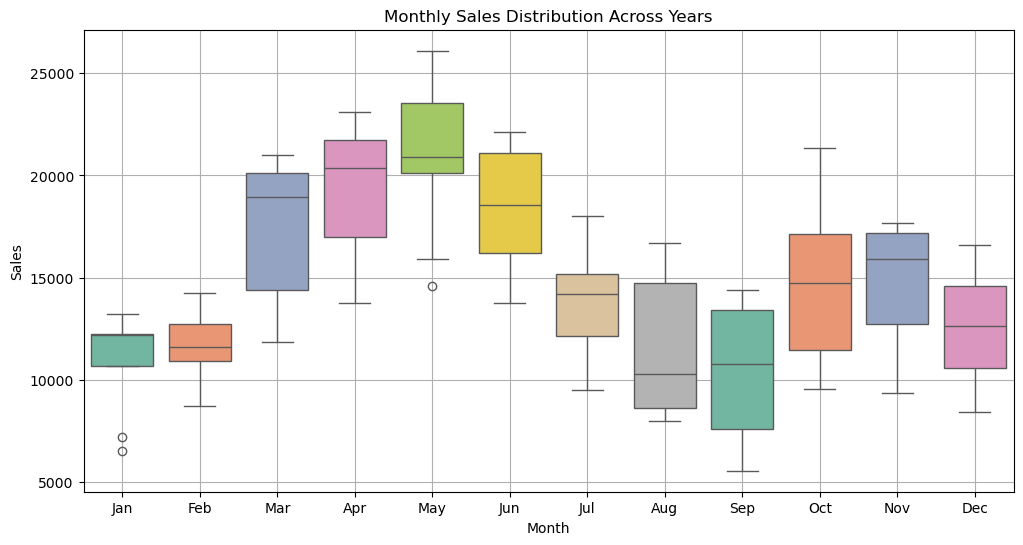

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from statsmodels.tsa.seasonal import seasonal_decompose



df.index = pd.to_datetime(df.index)
df = df.asfreq('MS') 


df['Month_Num'] = df.index.month
df['Month_Name'] = df['Month_Num'].apply(lambda x: calendar.month_abbr[x])
df['Year'] = df.index.year


decomposition = seasonal_decompose(df['Sales'], model='multiplicative', period=12)

plt.rcParams.update({'figure.figsize': (12, 8)})
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Sales (Multiplicative Model)", fontsize=16)
plt.tight_layout()
plt.show()


monthly_avg = df.groupby('Month_Name')['Sales'].mean()
monthly_avg = monthly_avg.reindex(list(calendar.month_abbr[1:]))

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='magma')
plt.title("Average Sales per Month (All Years)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()


seasonal_pivot = df.pivot_table(index='Month_Num', columns='Year', values='Sales')

plt.figure(figsize=(14, 7))
for year in seasonal_pivot.columns:
    plt.plot(seasonal_pivot.index, seasonal_pivot[year], marker='o', label=str(year))

plt.title("Monthly Sales Trends Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(x='Month_Name', y='Sales', data=df, order=calendar.month_abbr[1:], palette='Set2')
plt.title("Monthly Sales Distribution Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


df.drop(['Month_Num', 'Month_Name', 'Year'], axis=1, inplace=True)


In [ ]:
TREND 

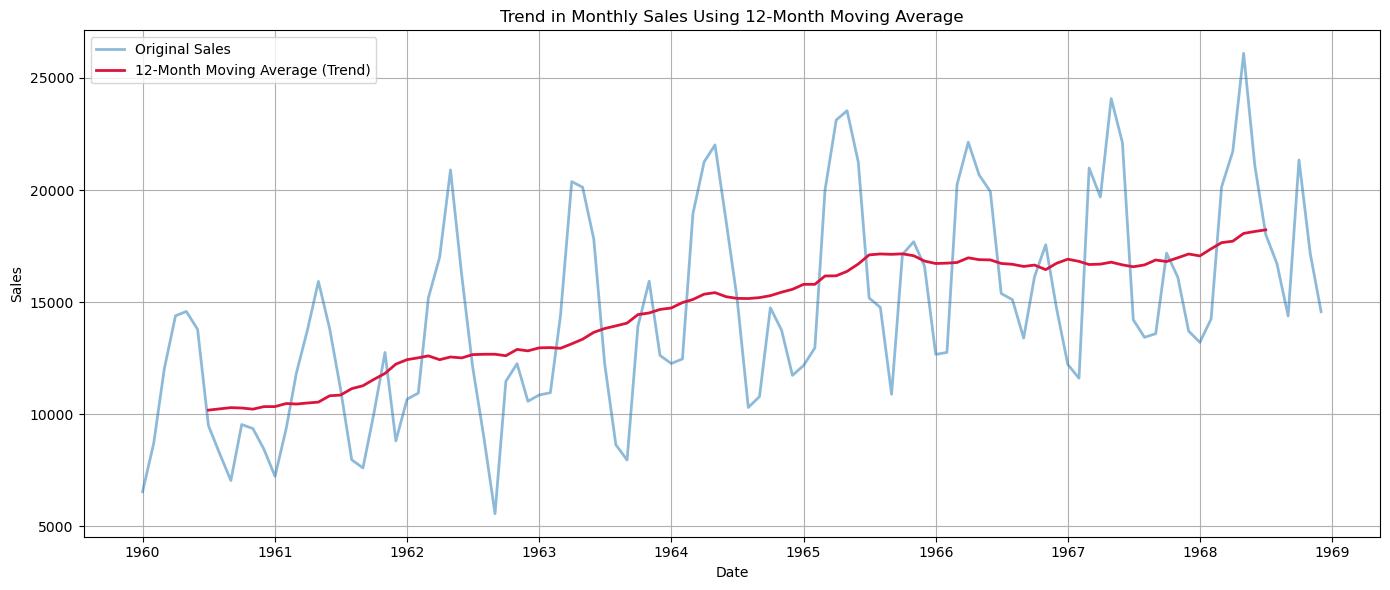

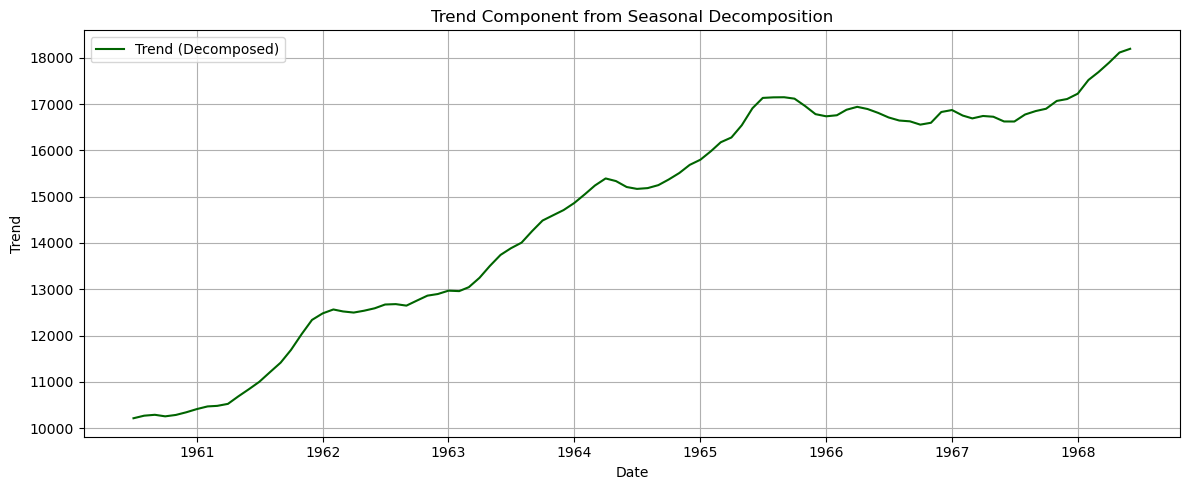

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')




df['Trend_MA_12'] = df['Sales'].rolling(window=12, center=True).mean()


plt.figure(figsize=(14, 6))
plt.plot(df['Sales'], label='Original Sales', alpha=0.5, linewidth=2)
plt.plot(df['Trend_MA_12'], label='12-Month Moving Average (Trend)', color='crimson', linewidth=2)
plt.title('Trend in Monthly Sales Using 12-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


decomp = seasonal_decompose(df['Sales'], model='multiplicative', period=12)


plt.figure(figsize=(12, 5))
plt.plot(decomp.trend, label='Trend (Decomposed)', color='darkgreen')
plt.title("Trend Component from Seasonal Decomposition")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


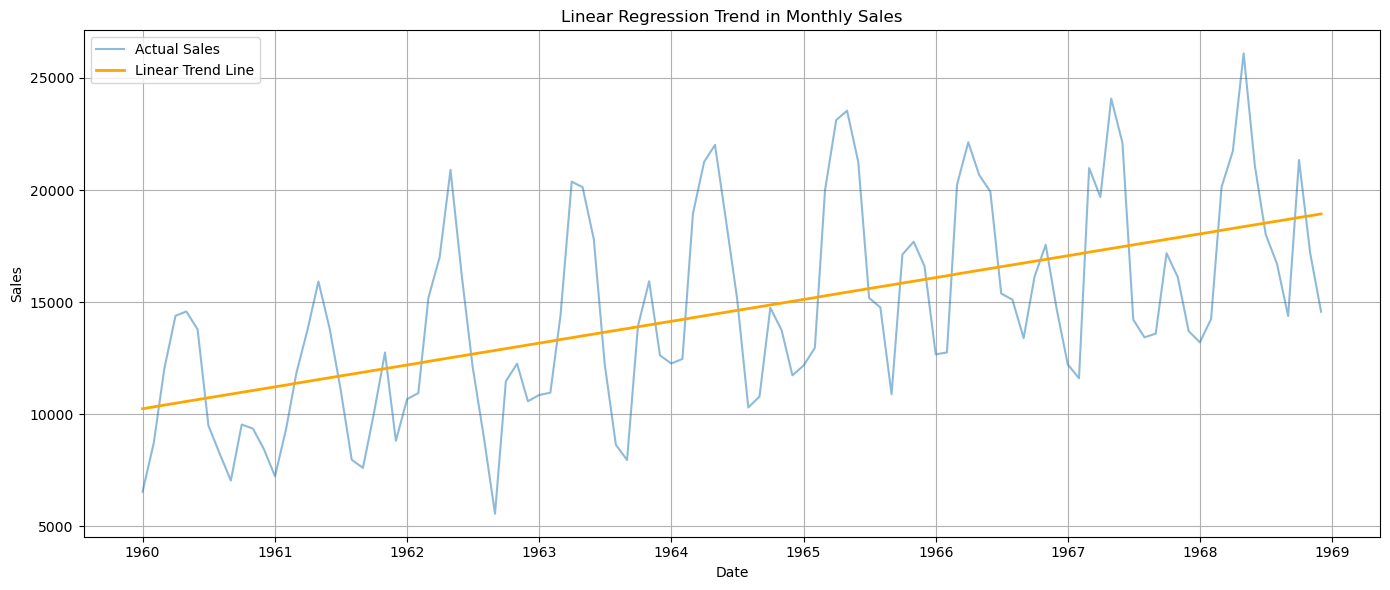

Slope of trend line: 81.20
Intercept: 10250.78


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from io import StringIO

data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')


df['TimeIndex'] = np.arange(len(df))


X = df['TimeIndex'].values.reshape(-1, 1)
y = df['Sales'].values


model = LinearRegression()
model.fit(X, y)


df['Trend_LR'] = model.predict(X)


plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Sales'], label='Actual Sales', alpha=0.5)
plt.plot(df.index, df['Trend_LR'], label='Linear Trend Line', color='orange', linewidth=2)
plt.title('Linear Regression Trend in Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print(f"Slope of trend line: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


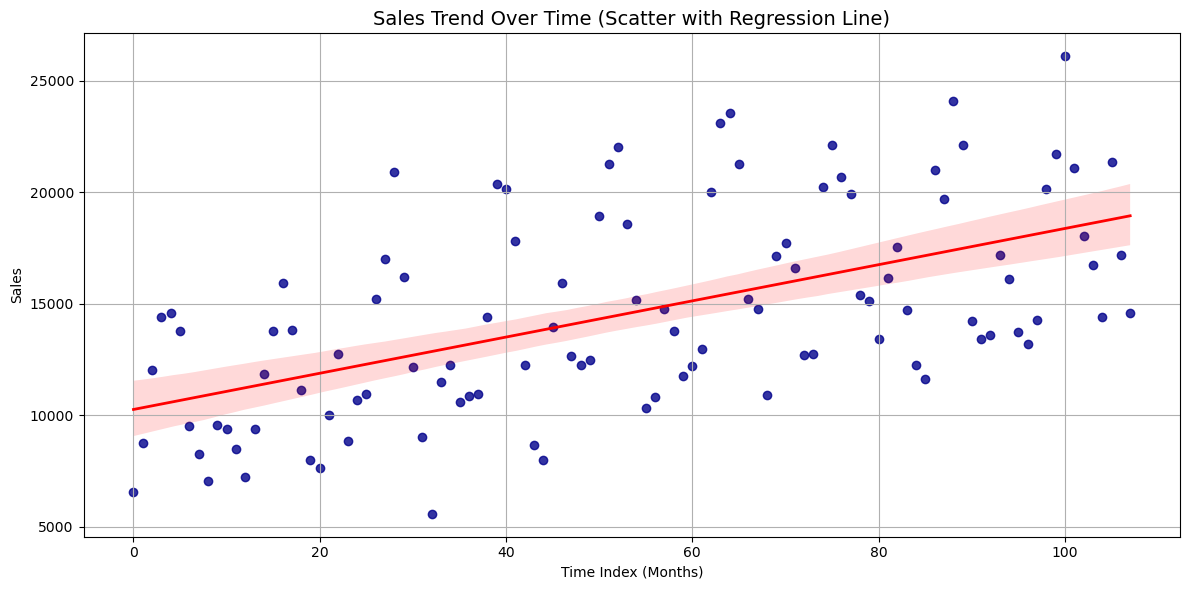

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')


df['TimeIndex'] = np.arange(len(df))  # Numeric time variable


plt.figure(figsize=(12, 6))
sns.regplot(x='TimeIndex', y='Sales', data=df, color='darkblue', line_kws={"color": "red", "linewidth": 2})
plt.title("Sales Trend Over Time (Scatter with Regression Line)", fontsize=14)
plt.xlabel("Time Index (Months)")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


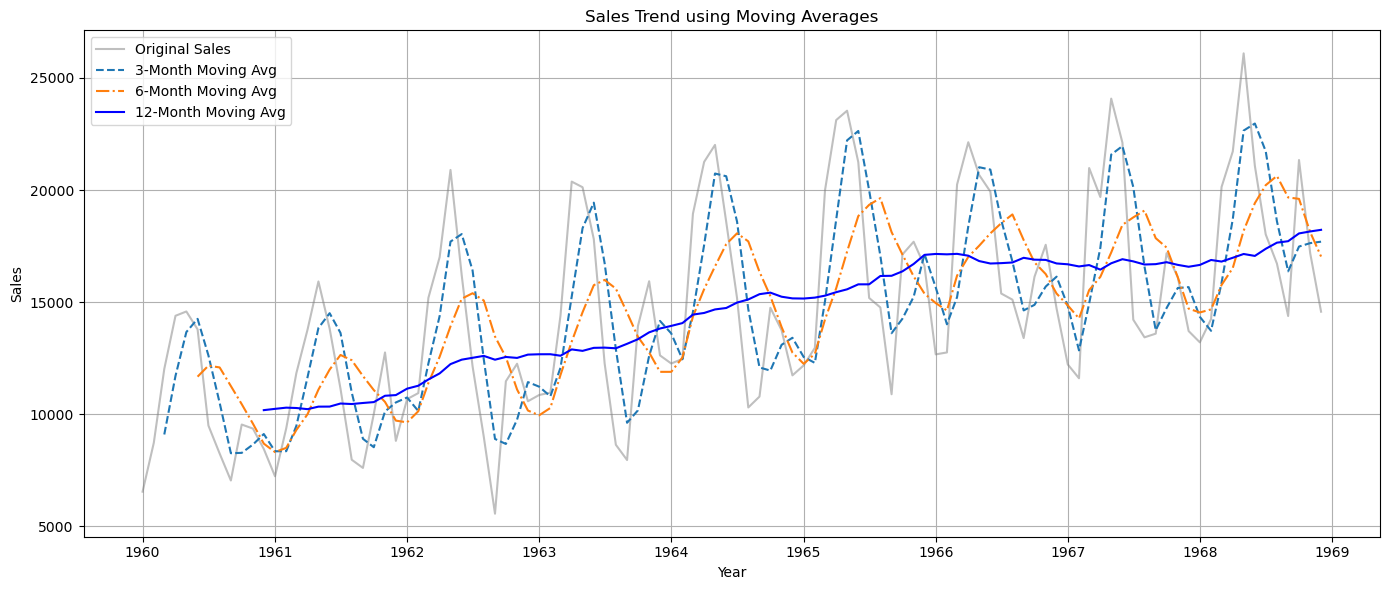

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')


df['MA_3'] = df['Sales'].rolling(window=3).mean()
df['MA_6'] = df['Sales'].rolling(window=6).mean()
df['MA_12'] = df['Sales'].rolling(window=12).mean()


plt.figure(figsize=(14, 6))
plt.plot(df['Sales'], label='Original Sales', color='gray', alpha=0.5)
plt.plot(df['MA_3'], label='3-Month Moving Avg', linestyle='--')
plt.plot(df['MA_6'], label='6-Month Moving Avg', linestyle='-.')
plt.plot(df['MA_12'], label='12-Month Moving Avg', color='blue')
plt.title('Sales Trend using Moving Averages')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

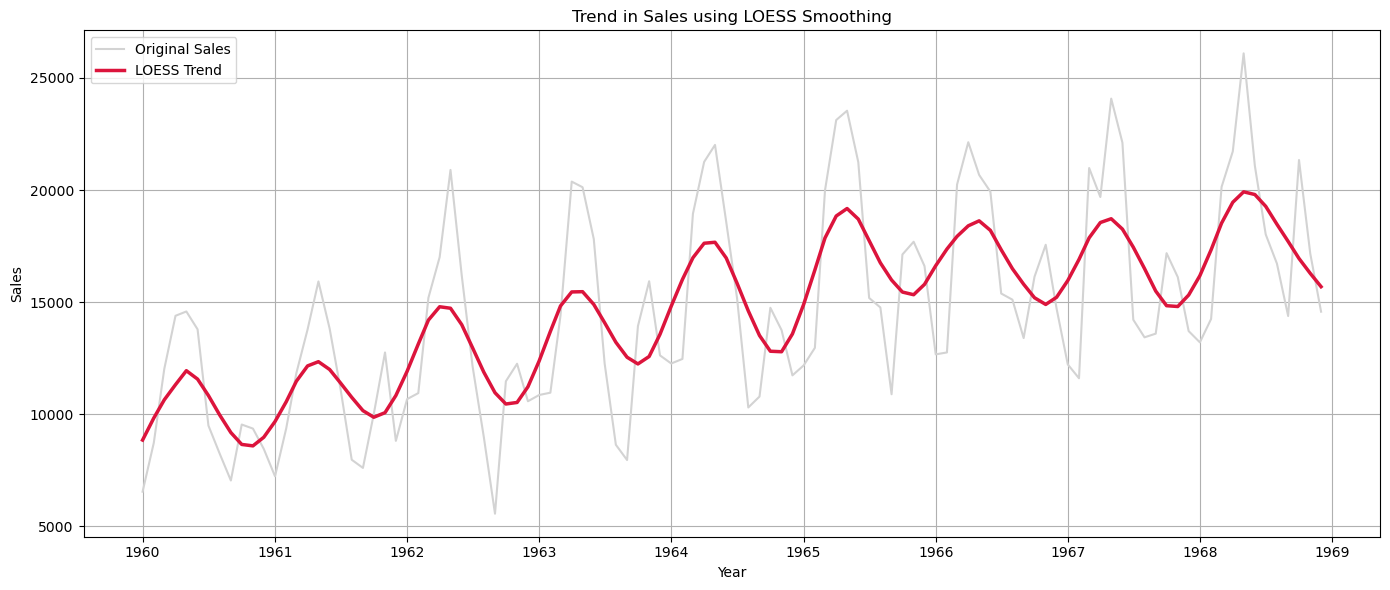

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')


df['TimeIndex'] = range(len(df))


lowess_result = lowess(endog=df['Sales'], exog=df['TimeIndex'], frac=0.1)
df['Lowess_Trend'] = lowess_result[:, 1]


plt.figure(figsize=(14, 6))
plt.plot(df['Sales'], label='Original Sales', color='lightgray')
plt.plot(df.index, df['Lowess_Trend'], color='crimson', linewidth=2.5, label='LOESS Trend')
plt.title("Trend in Sales using LOESS Smoothing")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

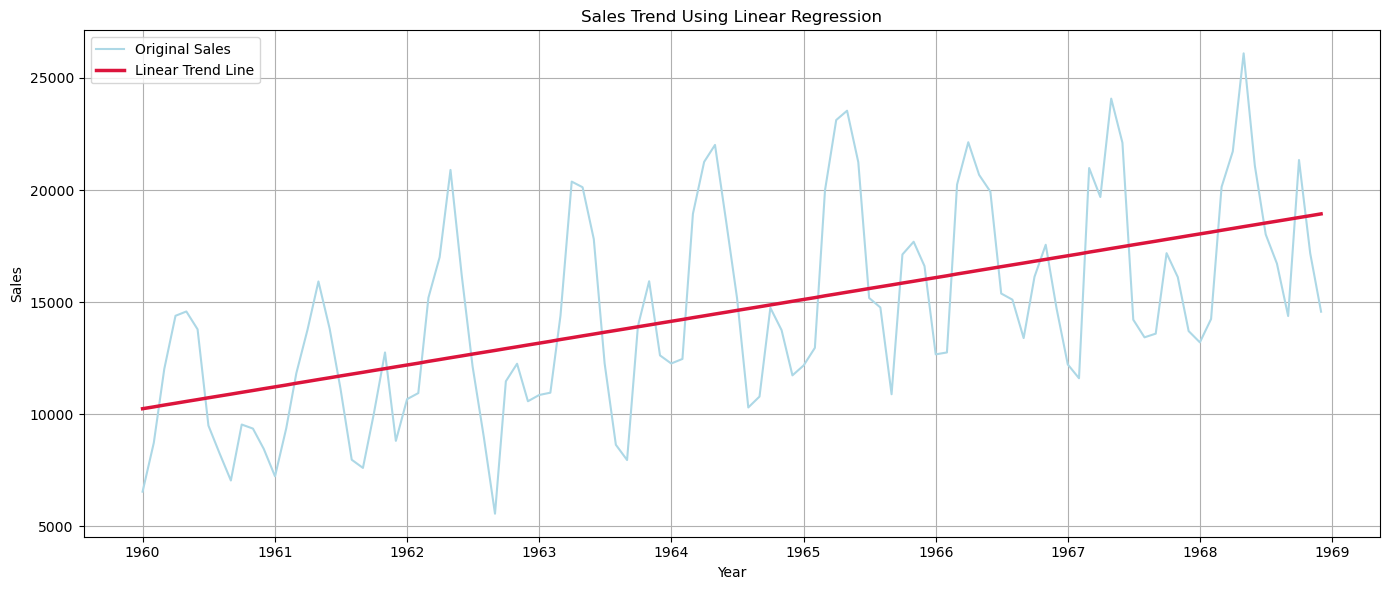

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from io import StringIO

data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')


df["TimeIndex"] = np.arange(len(df))  
X = df["TimeIndex"].values.reshape(-1, 1)
y = df["Sales"].values


model = LinearRegression()
model.fit(X, y)
df["Trend"] = model.predict(X)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Sales"], label="Original Sales", color='lightblue')
plt.plot(df.index, df["Trend"], label="Linear Trend Line", color="crimson", linewidth=2.5)
plt.title("Sales Trend Using Linear Regression")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

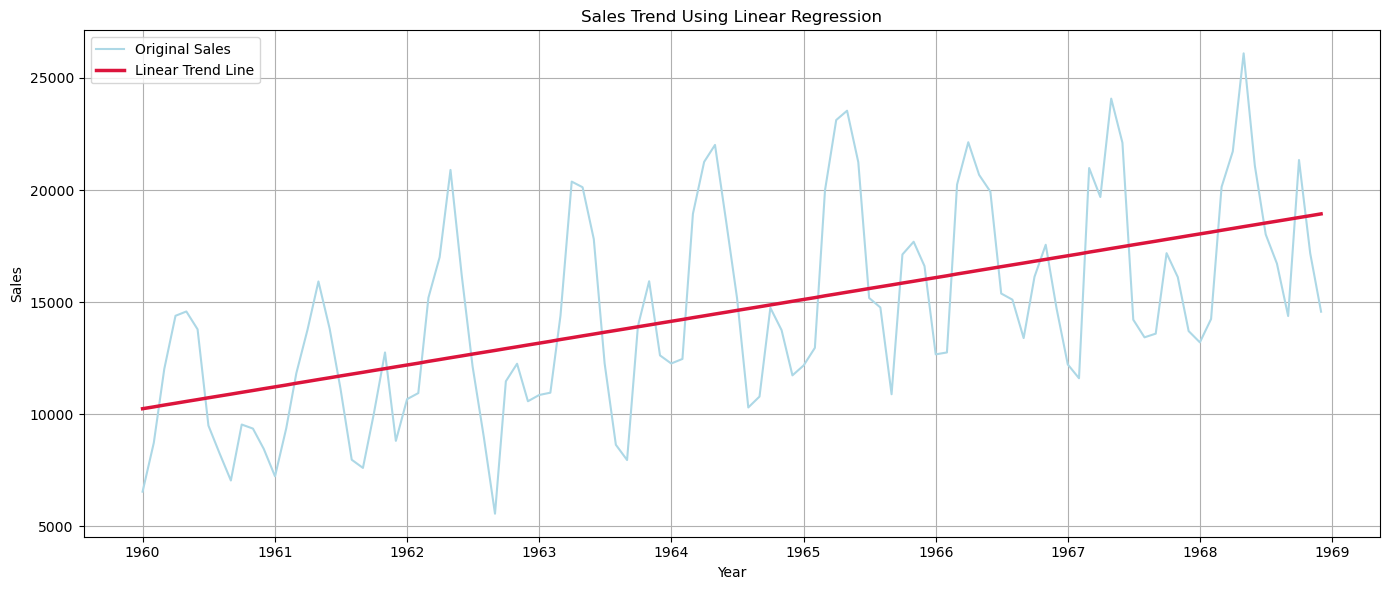

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from io import StringIO

data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""

df = pd.read_csv(StringIO(data), parse_dates=["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')


df["TimeIndex"] = np.arange(len(df)) 
X = df["TimeIndex"].values.reshape(-1, 1)
y = df["Sales"].values


model = LinearRegression()
model.fit(X, y)
df["Trend"] = model.predict(X)


plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Sales"], label="Original Sales", color='lightblue')
plt.plot(df.index, df["Trend"], label="Linear Trend Line", color="crimson", linewidth=2.5)
plt.title("Sales Trend Using Linear Regression")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Candlestick Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
from io import StringIO

In [ ]:
!pip install mplfinance

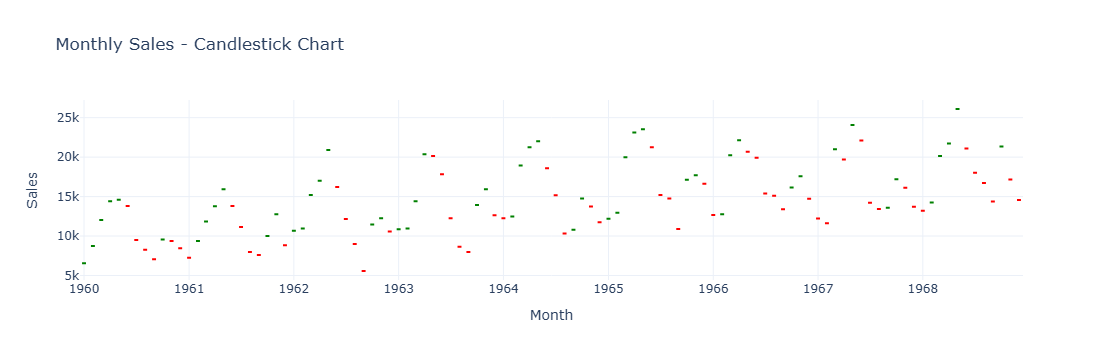

In [75]:
import pandas as pd
import plotly.graph_objects as go
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""


df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index("Month", inplace=True)


df["Open"] = df["Sales"]
df["High"] = df["Sales"]
df["Low"] = df["Sales"]
df["Close"] = df["Sales"]


fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df["Open"],
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

fig.update_layout(
    title='Monthly Sales - Candlestick Chart',
    xaxis_title='Month',
    yaxis_title='Sales',
    xaxis_rangeslider_visible=False,
    template="plotly_white"
)

fig.show()

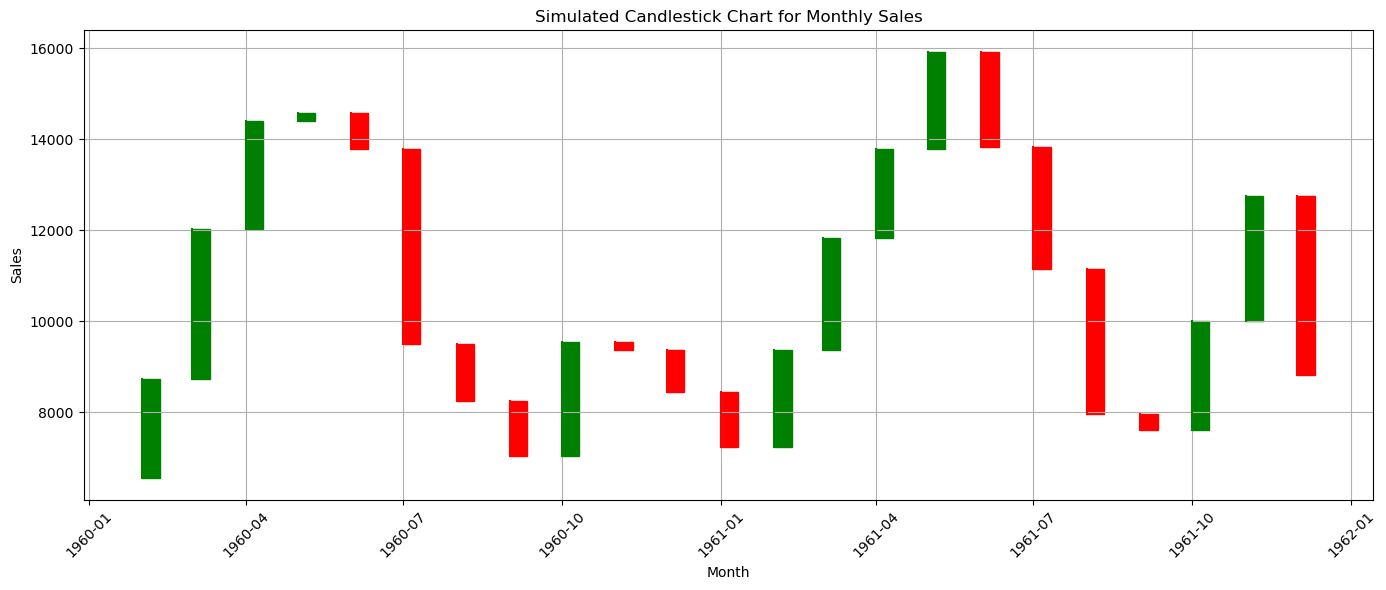

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816"""  


df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index("Month", inplace=True)
df = df.asfreq('MS')


df['Open'] = df['Sales'].shift(1)
df['Close'] = df['Sales']
df['High'] = df[['Open', 'Close']].max(axis=1)
df['Low'] = df[['Open', 'Close']].min(axis=1)


fig, ax = plt.subplots(figsize=(14, 6))

for i in range(1, len(df)):
    color = 'green' if df['Close'].iloc[i] >= df['Open'].iloc[i] else 'red'
    ax.plot([df.index[i], df.index[i]], [df['Low'].iloc[i], df['High'].iloc[i]], color=color)  # Wick
    ax.add_patch(plt.Rectangle(
        (df.index[i], min(df['Open'].iloc[i], df['Close'].iloc[i])),
        width=pd.Timedelta(days=10),
        height=abs(df['Open'].iloc[i] - df['Close'].iloc[i]),
        color=color
    ))

plt.title("Simulated Candlestick Chart for Monthly Sales")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

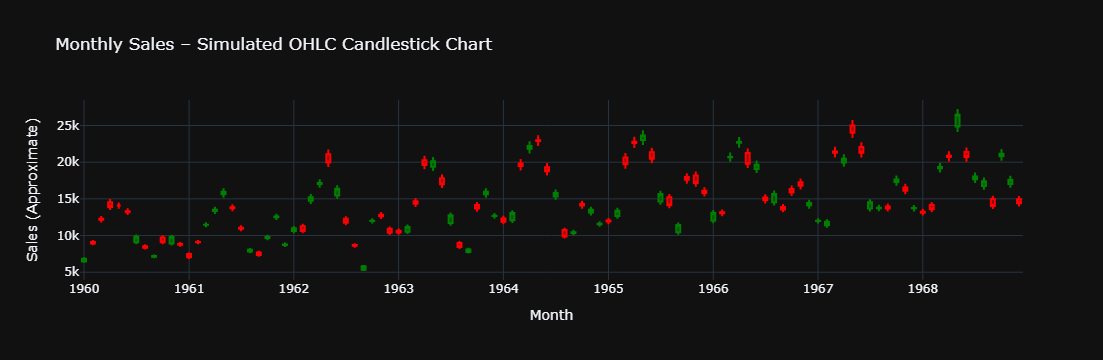

In [79]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""


df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index("Month", inplace=True)


np.random.seed(42)  
variation = np.random.uniform(0.95, 1.05, size=len(df))
df["Open"] = df["Sales"] * variation
df["Close"] = df["Sales"] * np.roll(variation, -1)
df["High"] = df[["Open", "Close"]].max(axis=1) * 1.03
df["Low"] = df[["Open", "Close"]].min(axis=1) * 0.97


fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df["Open"],
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    increasing_line_color='green',
    decreasing_line_color='red',
    name='Sales OHLC'
)])

fig.update_layout(
    title='Monthly Sales – Simulated OHLC Candlestick Chart',
    xaxis_title='Month',
    yaxis_title='Sales (Approximate)',
    template='plotly_dark',
    xaxis_rangeslider_visible=False
)

fig.show()

C:\Users\ldivy\AppData\Local\Temp\ipykernel_15440\29684898.py:128: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





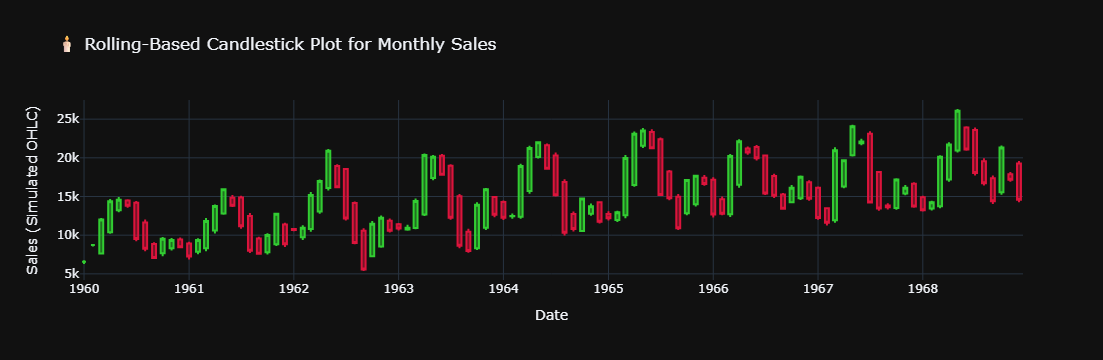

In [83]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from io import StringIO


data = """Month,Sales
1960-01,6550
1960-02,8728
1960-03,12026
1960-04,14395
1960-05,14587
1960-06,13791
1960-07,9498
1960-08,8251
1960-09,7049
1960-10,9545
1960-11,9364
1960-12,8456
1961-01,7237
1961-02,9374
1961-03,11837
1961-04,13784
1961-05,15926
1961-06,13821
1961-07,11143
1961-08,7975
1961-09,7610
1961-10,10015
1961-11,12759
1961-12,8816
1962-01,10677
1962-02,10947
1962-03,15200
1962-04,17010
1962-05,20900
1962-06,16205
1962-07,12143
1962-08,8997
1962-09,5568
1962-10,11474
1962-11,12256
1962-12,10583
1963-01,10862
1963-02,10965
1963-03,14405
1963-04,20379
1963-05,20128
1963-06,17816
1963-07,12268
1963-08,8642
1963-09,7962
1963-10,13932
1963-11,15936
1963-12,12628
1964-01,12267
1964-02,12470
1964-03,18944
1964-04,21259
1964-05,22015
1964-06,18581
1964-07,15175
1964-08,10306
1964-09,10792
1964-10,14752
1964-11,13754
1964-12,11738
1965-01,12181
1965-02,12965
1965-03,19990
1965-04,23125
1965-05,23541
1965-06,21247
1965-07,15189
1965-08,14767
1965-09,10895
1965-10,17130
1965-11,17697
1965-12,16611
1966-01,12674
1966-02,12760
1966-03,20249
1966-04,22135
1966-05,20677
1966-06,19933
1966-07,15388
1966-08,15113
1966-09,13401
1966-10,16135
1966-11,17562
1966-12,14720
1967-01,12225
1967-02,11608
1967-03,20985
1967-04,19692
1967-05,24081
1967-06,22114
1967-07,14220
1967-08,13434
1967-09,13598
1967-10,17187
1967-11,16119
1967-12,13713
1968-01,13210
1968-02,14251
1968-03,20139
1968-04,21725
1968-05,26099
1968-06,21084
1968-07,18024
1968-08,16722
1968-09,14385
1968-10,21342
1968-11,17180
1968-12,14577"""


df = pd.read_csv(StringIO(data), parse_dates=['Month'])
df.set_index('Month', inplace=True)


df['Open'] = df['Sales'].shift(1).rolling(window=2).mean()
df['Close'] = df['Sales']
df['High'] = df[['Open', 'Close']].max(axis=1) + np.random.randint(100, 400, size=len(df))
df['Low'] = df[['Open', 'Close']].min(axis=1) - np.random.randint(100, 400, size=len(df))


df['Open'].fillna(df['Sales'], inplace=True)


fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df["Open"],
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    increasing_line_color='limegreen',
    decreasing_line_color='crimson',
    name='Sales'
)])

fig.update_layout(
    title="🕯️ Rolling-Based Candlestick Plot for Monthly Sales",
    xaxis_title="Date",
    yaxis_title="Sales (Simulated OHLC)",
    xaxis_rangeslider_visible=False,
    template="plotly_dark"
)

fig.show()